In [26]:
#library python yg dibutuhkan

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [27]:
#load dataset
dataset_path = "dataset"
img_size = 224
batch_size = 32

In [28]:
#preproccess dataset
import os

path = ("dataset")
dataset_dir = os.path.join(path,)

print("kategori : ", os.listdir(dataset_dir))

kategori :  ['pituitary', 'notumor', 'glioma', 'meningioma']


In [29]:
#split dataset untuk membagi menjadi 3 folder train/val/test 
#train : 80% 
#val : 10%
#test : 10%

import os
import shutil
import random

def prepare_dataset(original_dir, base_output, split_ratio=0.8):
    if not os.path.exists(base_output):
        os.makedirs(base_output)
        
    train_dir = os.path.join(base_output, "Train")
    val_dir = os.path.join(base_output, "Val")
    test_dir = os.path.join(base_output, "Test")
    
    # Membuat folder utama jika belum ada
    for d in [train_dir, val_dir, test_dir]:
        os.makedirs(d, exist_ok=True)
    
    for class_name in os.listdir(original_dir):
        class_path = os.path.join(original_dir, class_name)
        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
            random.shuffle(images)
            
            # Menghitung titik potong (Split Points)
            train_count = int(len(images) * split_ratio)
            # Sisa 20% dibagi dua: 10% Val, 10% Test
            val_count = int((len(images) - train_count) / 2)
            val_split_idx = train_count + val_count
            
            for i, img in enumerate(images):
                if i < train_count:
                    target_dir = train_dir
                elif i < val_split_idx:
                    target_dir = val_dir
                else:
                    target_dir = test_dir
                
                class_target_dir = os.path.join(target_dir, class_name)
                os.makedirs(class_target_dir, exist_ok=True)
                
                src = os.path.join(class_path, img)
                dst = os.path.join(class_target_dir, img)
                shutil.copyfile(src, dst)
                
    # Urutan return disesuaikan dengan variabel penampung Anda
    return train_dir, val_dir, test_dir

# Contoh penggunaan:
dataset_dir = "dataset" 
train_path, val_path, test_path = prepare_dataset(dataset_dir, "dataset_split")

print(f"Selesai! Data tersimpan di {train_path}, {val_path}, dan {test_path}")

Selesai! Data tersimpan di dataset_split/Train, dataset_split/Val, dan dataset_split/Test


In [30]:
#augmentasi dataset

import os
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input 
#hapus jika tidak mau pakai preproccess input

# --- LANGKAH 1: Definisikan Nama Folder Dataset Asli Anda ---
# Ganti "NAMA_FOLDER_ASLI_ANDA" dengan nama folder tempat gambar Anda berada
dataset_dir = "dataset" 

# --- LANGKAH 2: Panggil Fungsi Prepare Dataset ---
# Ini langkah kunci agar train_dir, val_dir, dan test_dir terisi
train_dir, val_dir, test_dir = prepare_dataset(dataset_dir, "dataset_split")

# --- LANGKAH 3: Jalankan ImageDataGenerator (Kode Anda) ---
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Augmentasi untuk Training
train_datagen = ImageDataGenerator(
    # rescale=1./255,(kode lama)
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Rescale untuk Val dan Test
# kode lama(val_datagen = ImageDataGenerator(rescale=1./255))
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Load Data - Sekarang variabel train_dir dkk sudah aman
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False 
)

Found 6853 images belonging to 4 classes.
Found 1346 images belonging to 4 classes.
Found 1364 images belonging to 4 classes.


In [31]:
#memasukkan arsitektur mobilenetv2
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [33]:
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [34]:
import tensorflow as tf
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,624,452 (10.01 MB)

 Trainable params: 1,890,308 (7.21 MB)

 Non-trainable params: 734,144 (2.80 MB)

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

EPOCHS = 20
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "model3.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [36]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


/Users/ahmadzaky/Documents/brain_tumor_mri/venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.5755 - loss: 1.1012

215/215 ━━━━━━━━━━━━━━━━━━━━ 74s 326ms/step - accuracy: 0.5761 - loss: 1.0996 - val_accuracy: 0.8128 - val_loss: 0.4918 - learning_rate: 1.0000e-04
Epoch 2/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.8380 - loss: 0.4550

215/215 ━━━━━━━━━━━━━━━━━━━━ 82s 379ms/step - accuracy: 0.8380 - loss: 0.4549 - val_accuracy: 0.8588 - val_loss: 0.3589 - learning_rate: 1.0000e-04
Epoch 3/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.8739 - loss: 0.3441

215/215 ━━━━━━━━━━━━━━━━━━━━ 83s 386ms/step - accuracy: 0.8740 - loss: 0.3440 - val_accuracy: 0.8863 - val_loss: 0.3249 - learning_rate: 1.0000e-04
Epoch 4/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.9012 - loss: 0.2749

...

215/215 ━━━━━━━━━━━━━━━━━━━━ 99s 461ms/step - accuracy: 0.9556 - loss: 0.1223 - val_accuracy: 0.9837 - val_loss: 0.0402 - learning_rate: 1.0000e-04
Epoch 12/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 97s 451ms/step - accuracy: 0.9536 - loss: 0.1206 - val_accuracy: 0.9755 - val_loss: 0.0832 - learning_rate: 1.0000e-04
Epoch 13/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 101s 469ms/step - accuracy: 0.9631 - loss: 0.1055 - val_accuracy: 0.9755 - val_loss: 0.0711 - learning_rate: 1.0000e-04
Epoch 14/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 105s 485ms/step - accuracy: 0.9676 - loss: 0.1003 - val_accuracy: 0.9822 - val_loss: 0.0386 - learning_rate: 1.0000e-04
Epoch 15/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.9681 - loss: 0.0980

215/215 ━━━━━━━━━━━━━━━━━━━━ 104s 482ms/step - accuracy: 0.9681 - loss: 0.0980 - val_accuracy: 0.9859 - val_loss: 0.0369 - learning_rate: 1.0000e-04
Epoch 16/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9716 - loss: 0.0948

215/215 ━━━━━━━━━━━━━━━━━━━━ 106s 492ms/step - accuracy: 0.9716 - loss: 0.0948 - val_accuracy: 0.9881 - val_loss: 0.0309 - learning_rate: 1.0000e-04
Epoch 17/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9693 - loss: 0.0953

215/215 ━━━━━━━━━━━━━━━━━━━━ 103s 479ms/step - accuracy: 0.9693 - loss: 0.0952 - val_accuracy: 0.9889 - val_loss: 0.0256 - learning_rate: 1.0000e-04
Epoch 18/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 102s 474ms/step - accuracy: 0.9734 - loss: 0.0922 - val_accuracy: 0.9889 - val_loss: 0.0358 - learning_rate: 1.0000e-04
Epoch 19/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9751 - loss: 0.0727

215/215 ━━━━━━━━━━━━━━━━━━━━ 102s 475ms/step - accuracy: 0.9751 - loss: 0.0727 - val_accuracy: 0.9918 - val_loss: 0.0231 - learning_rate: 1.0000e-04
Epoch 20/20
215/215 ━━━━━━━━━━━━━━━━━━━━ 106s 491ms/step - accuracy: 0.9719 - loss: 0.0765 - val_accuracy: 0.9911 - val_loss: 0.0278 - learning_rate: 1.0000e-04


Found 1346 images belonging to 4 classes.
Sedang mengevaluasi model...
43/43 ━━━━━━━━━━━━━━━━━━━━ 11s 234ms/step

=== Classification Report ===
              precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       305
  meningioma       0.98      0.99      0.98       334
     notumor       1.00      1.00      1.00       374
   pituitary       0.99      1.00      0.99       333

    accuracy                           0.99      1346
   macro avg       0.99      0.99      0.99      1346
weighted avg       0.99      0.99      0.99      1346



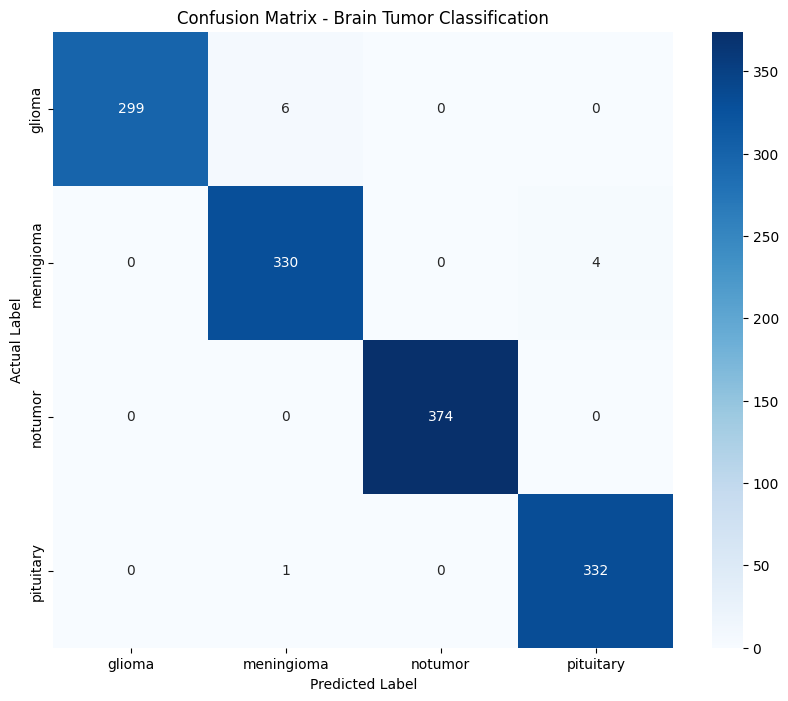

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input #ganti

# 1. Load Model yang sudah disimpan (sesuaikan nama file)
model = load_model('model3.h5') 

# 2. Siapkan Data Validasi untuk Evaluasi
# Sesuaikan IMG_SIZE dengan yang Anda gunakan saat training (misal: 150 atau 224)
IMG_SIZE = (224, 224) 
BATCH_SIZE = 32
val_dir = 'dataset_split/Val' 

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # WAJIB False agar urutan prediksi tidak acak
)

# 3. Lakukan Prediksi
print("Sedang mengevaluasi model...")
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_generator.classes
class_names = list(val_generator.class_indices.keys())

# 4. Menampilkan Classification Report (F1-Score, Precision, Recall)
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5. Membuat Confusion Matrix (seperti di foto IMG_5205.jpg)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Brain Tumor Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. Menampilkan Grafik Akurasi & Loss (Opsional, jika variabel 'history' masih ada)
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    
    # Grafik Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Grafik Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()

# Panggil fungsi plot jika Anda baru saja selesai training
# plot_history(history)